In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

Define LSTM Architecture

In [61]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2, num_classes=3):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.attention_network = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.fc1 = nn.Linear(hidden_size, 64)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # (batch, seq, hidden)

        # Apply attention correctly
        attn_scores = self.attention_network(lstm_out).squeeze(-1)  # (batch, seq)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)  # (batch, seq, 1)
        context = torch.sum(attn_weights * lstm_out, dim=1)  # (batch, hidden)

        out = self.fc1(context)
        out = torch.relu(out)
        out = self.dropout(out)
        return self.fc2(out)


More Indicators - Eventually move to dataEngineering file

In [62]:
def compute_technical_indicators(df):
    """Compute technical indicators with proper handling of NaN values"""
    # Price and volume features
    df['Returns'] = df['Close'].pct_change()
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Volume_Change'] = df['Volume'].pct_change()
    
    # Moving averages
    for window in [5, 10, 20, 50]:
        df[f'SMA_{window}'] = df['Close'].rolling(window=window).mean()
        df[f'EMA_{window}'] = df['Close'].ewm(span=window, adjust=False).mean()
    
    # Price relative to moving averages
    df['Price_to_SMA50'] = df['Close'] / df['SMA_50']
    df['Price_to_SMA200'] = df['Close'] / df['Close'].rolling(window=200).mean()
    
    # Volatility indicators
    df['Volatility_10'] = df['Returns'].rolling(window=10).std()
    df['Volatility_30'] = df['Returns'].rolling(window=30).std()
    
    # RSI
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(window=14).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    # MACD
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    
    # Bollinger Bands
    df['BB_Middle'] = df['Close'].rolling(window=20).mean()
    df['BB_Std'] = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Middle'] + 2 * df['BB_Std']
    df['BB_Lower'] = df['BB_Middle'] - 2 * df['BB_Std']
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']
    
    # Momentum indicators
    for window in [5, 10, 20]:
        df[f'Momentum_{window}'] = df['Close'] - df['Close'].shift(window)
        df[f'ROC_{window}'] = df['Close'].pct_change(periods=window) * 100
    
    # Clean up NaN values
    df = df.replace([np.inf, -np.inf], np.nan)
    
    return df

In [63]:
def prepare_data(df, feature_columns, target_column='Returns', seq_length=20, prediction_horizon=5, threshold_pct=0.005):
    df = df.sort_index()

    print("Initial shape:", df.shape)

    # Compute future returns
    df['Future_Return'] = df[target_column].shift(-prediction_horizon).rolling(window=prediction_horizon).sum()

    # Compute volatility
    volatility = df[target_column].rolling(window=30).std()
    upper_threshold = threshold_pct * volatility
    lower_threshold = -threshold_pct * volatility

    # Classification labels
    conditions = [
        df['Future_Return'] > upper_threshold,
        df['Future_Return'] < lower_threshold
    ]
    choices = [2, 0]
    df['Target'] = np.select(conditions, choices, default=1)

    # Drop rows with NaNs now that all necessary columns are computed
    df = df.dropna(subset=feature_columns + ['Future_Return', target_column])

    print("After dropna, shape:", df.shape)

    # Normalize features
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df[feature_columns]),
        columns=feature_columns,
        index=df.index
    )

    # Create sequences
    X, y, dates = [], [], []
    for i in range(seq_length, len(df_scaled) - prediction_horizon):
        X.append(df_scaled.iloc[i-seq_length:i].values)
        y.append(df['Target'].iloc[i])
        dates.append(df.index[i])

    X = np.array(X)
    y = np.array(y)
    dates = pd.DatetimeIndex(dates)

    print(f"Final dataset: X={X.shape}, y={y.shape}, dates={dates.shape}")

    # Time-based split
    train_size = int(len(X) * 0.7)
    val_size = int(len(X) * 0.15)

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
    X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]
    test_dates = dates[train_size+val_size:]
    
    test_start_idx = df.index.get_loc(test_dates[0])

    return X_train, y_train, X_val, y_val, X_test, y_test, test_dates, scaler, test_start_idx

# Missing from your code - proper time series split
def time_series_split(df, test_size=0.2, val_size=0.2):
    """Split data chronologically instead of randomly"""
    n = len(df)
    test_idx = int(n * (1 - test_size))
    val_idx = int(test_idx * (1 - val_size))
    
    train = df.iloc[:val_idx]
    val = df.iloc[val_idx:test_idx]
    test = df.iloc[test_idx:]
    
    return train, val, test


In [64]:
def train_enhanced_lstm(X_train, y_train, X_val, y_val, input_size, 
                        hidden_size=128, num_layers=2, dropout=0.2, 
                        epochs=50, batch_size=64, learning_rate=0.001, 
                        patience=10, class_weights=None,
                        device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Train LSTM model with early stopping and learning rate scheduling
    """
    # Convert to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val = torch.tensor(y_val, dtype=torch.long).to(device)
    
    # Initialize model
    model = LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)
    
    # Loss function with class weights if provided
    if class_weights is not None:
        weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)
    else:
        criterion = nn.CrossEntropyLoss()
    
    # Optimizer with weight decay (L2 regularization)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )
    
    # Training loop with early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        permutation = torch.randperm(X_train.size(0))
        
        for i in range(0, X_train.size(0), batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X_train[indices], y_train[indices]
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item() * batch_x.size(0)
        
        train_loss /= X_train.size(0)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for i in range(0, X_val.size(0), batch_size):
                batch_x = X_val[i:i+batch_size]
                batch_y = y_val[i:i+batch_size]
                
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == batch_y).sum().item()
        
        val_loss /= X_val.size(0)
        val_accuracy = correct / X_val.size(0)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        feature_columns = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'Returns', 'Log_Returns', 'SMA_5', 'EMA_2',
        'RSI', 'MACD', 'MACD_Signal', 'MACD_Diff',
        'BB_High', 'BB_Low', 'Volume_EMA', 'Volatility'
        ]
        
        # Save best model
        model_name = f"lstm_input{len(feature_columns)}_hidden{hidden_size}_layers{num_layers}_drop{int(dropout*100)}.pth"
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_name)
        # else:
        #     patience_counter += 1
        #     if patience_counter >= patience:
        #         print("Early stopping triggered.")
        #         break


        
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
    
    # Load best model
    model.load_state_dict(torch.load(model_name))
    
    return model, train_losses, val_losses, val_accuracies

In [65]:
def evaluate_model(model, X_test, y_test, test_start_idx, batch_size=64, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Evaluate model on test set with detailed metrics
    """
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)
    
    model.eval()
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for i in range(0, X_test.size(0), batch_size):
            batch_x = X_test[i:i+batch_size]
            outputs = model(batch_x)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    y_test_np = y_test.cpu().numpy()

    print("\nClassification Report:")
    print(classification_report(y_test_np, all_preds, target_names=['Sell', 'Hold', 'Buy']))
    
    # Assuming:
    # all_preds contains integers: 0 = Sell, 1 = Hold, 2 = Buy

    mapping = {0: -1, 1: 0, 2: 1}
    signals = np.vectorize(mapping.get)(all_preds)
    
    # signals_full = np.zeros(len(df))  # or np.full(len(df), np.nan)
    # signals_full[test_start_idx:test_start_idx + len(signals)] = signals
    

    # Confusion matrix
    cm = confusion_matrix(y_test_np, all_preds)
    print("\nConfusion Matrix:")
    print(cm)
    
    # Overall accuracy
    accuracy = (all_preds == y_test_np).mean()
    print(f"\nTest Accuracy: {accuracy:.4f}")
    
    return all_preds, all_probs, signals 

In [ ]:
# import pandas as pd
# from io import StringIO

# # Step 1: Remove starting/ending quotes and add trailing comma
# with open("All_Stock_Data.csv", "r") as f:
#     cleaned_lines = [
#         (line[1:-2] if line.endswith('\n') else line[1:-1]) + ','  # strip quotes, add comma
#         for line in f
#     ]

# # Step 2: Write cleaned lines to a new CSV file
# with open("cleaned_file.csv", "w") as f:
#     for line in cleaned_lines:
#         f.write(line + '\n')  # ensure newline at end of each line

In [66]:
feature_columns = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Returns', 'Log_Returns', 'SMA_5', 'EMA_2',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Diff',
    'BB_High', 'BB_Low', 'Volume_EMA', 'Volatility'
]

df = pd.read_csv('cleaned_file.csv', parse_dates=['Datetime'], index_col='Datetime')
df = df.dropna(subset=feature_columns) # then drop only if required
# df = df.drop('Unnamed: 19', axis=1)
print("DataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumns available:")
print(df.columns.tolist())

DataFrame shape: (417079, 19)

First few rows:
                         Open      High       Low    Close   Volume Ticker  \
Datetime                                                                     
2025-03-12 05:00:00  220.6000  220.8100  220.6000  220.800   3941.0   AAPL   
2025-03-12 05:00:00  110.3200  110.3800  110.3000  110.370   8421.0   NVDA   
2025-03-12 05:00:00  191.8759  191.8759  191.8061  191.846    326.0   AVGO   
2025-03-12 05:00:00   21.4100   21.4100   21.3700   21.370  10334.0   INTC   
2025-03-12 05:00:00  383.1500  383.1500  383.1500  383.150      1.0   MSFT   

                      Returns  Log_Returns      SMA_5       EMA_2        RSI  \
Datetime                                                                       
2025-03-12 05:00:00  0.000952     0.000952  220.61200  220.730627  73.503526   
2025-03-12 05:00:00  0.000272     0.000272  110.32800  110.360319  63.674896   
2025-03-12 05:00:00 -0.000156    -0.000156  191.69642  191.832628  62.185993   
2025-0

In [74]:
# Example usage (commented out as we don't have the actual data)
# Define features
feature_columns = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Returns', 'Log_Returns', 'SMA_5', 'EMA_2',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Diff',
    'BB_High', 'BB_Low', 'Volume_EMA', 'Volatility'
]

# Load and preprocess data
df = compute_technical_indicators(df)  # apply indicators first
df = df.dropna(subset=feature_columns) # then drop only if required
# df = df.drop('Unnamed: 19', axis=1)

# Prepare data
X_train, y_train, X_val, y_val, X_test, y_test, test_dates, scaler, test_start_idx = prepare_data(
    df, feature_columns, seq_length=30, prediction_horizon=5
)

# Calculate class weights to handle imbalance
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / np.sum(class_weights) * len(class_weights)

# Train model
model, train_losses, val_losses, val_accuracies = train_enhanced_lstm(
    X_train, y_train, X_val, y_val, 
    input_size=len(feature_columns),
    hidden_size=128,
    num_layers=2,
    dropout=0.3,
    epochs=30,
    batch_size=64,
    learning_rate=0.001,
    patience=10,
    class_weights=class_weights
)

# Evaluate model
predictions, probabilities, signals = evaluate_model(
    model, X_test, y_test, test_start_idx=test_start_idx
)

# Backtest strategy
#backtest_results = backtest_strategy(predictions, test_dates, df)

# This is a placeholder for demonstration - in a real scenario, you would run the above code with actual data
print("Enhanced LSTM model for stock prediction with proper time series handling, attention mechanism, and realistic backtesting")

Initial shape: (417063, 44)
After dropna, shape: (417054, 46)
Final dataset: X=(417019, 30, 17), y=(417019,), dates=(417019,)


/Users/amarpritsingh/anaconda3/envs/rnn_development/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30 - Train Loss: 1.1151, Val Loss: 1.0070, Val Acc: 0.9179
Epoch 2/30 - Train Loss: 1.0869, Val Loss: 1.0129, Val Acc: 0.9179
Epoch 3/30 - Train Loss: 1.0728, Val Loss: 1.0145, Val Acc: 0.9179
Epoch 4/30 - Train Loss: 1.0643, Val Loss: 1.0326, Val Acc: 0.1387
Epoch 5/30 - Train Loss: 1.0623, Val Loss: 0.9857, Val Acc: 0.9179
Epoch 6/30 - Train Loss: 1.0569, Val Loss: 1.0608, Val Acc: 0.9179
Epoch 7/30 - Train Loss: 1.0764, Val Loss: 0.9924, Val Acc: 0.9179
Epoch 8/30 - Train Loss: 1.0756, Val Loss: 1.0236, Val Acc: 0.9179
Epoch 9/30 - Train Loss: 1.0652, Val Loss: 0.9794, Val Acc: 0.9179
Epoch 10/30 - Train Loss: 1.1018, Val Loss: 1.1439, Val Acc: 0.1949
Epoch 11/30 - Train Loss: 1.0766, Val Loss: 0.9772, Val Acc: 0.9179
Epoch 12/30 - Train Loss: 1.0603, Val Loss: 1.0345, Val Acc: 0.9179
Epoch 13/30 - Train Loss: 1.0586, Val Loss: 1.0058, Val Acc: 0.9179
Epoch 14/30 - Train Loss: 1.0474, Val Loss: 0.9738, Val Acc: 0.9179
Epoch 15/30 - Train Loss: 1.0464, Val Loss: 1.0298, Val A

/var/folders/t_/1j24y4gj22q4lrhhw9bl5n600000gn/T/ipykernel_31490/3918135168.py:117: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_name


Classification Report:
              precision    recall  f1-score   support

        Sell       0.00      0.00      0.00      4719
        Hold       0.00      0.00      0.00       231
         Buy       0.92      1.00      0.96     57604

    accuracy                           0.92     62554
   macro avg       0.31      0.33      0.32     62554
weighted avg       0.85      0.92      0.88     62554


Confusion Matrix:
[[    0     0  4719]
 [    0     0   231]
 [    0     0 57604]]

Test Accuracy: 0.9209
Enhanced LSTM model for stock prediction with proper time series handling, attention mechanism, and realistic backtesting


/Users/amarpritsingh/anaconda3/envs/rnn_development/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/amarpritsingh/anaconda3/envs/rnn_development/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/amarpritsingh/anaconda3/envs/rnn_development/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

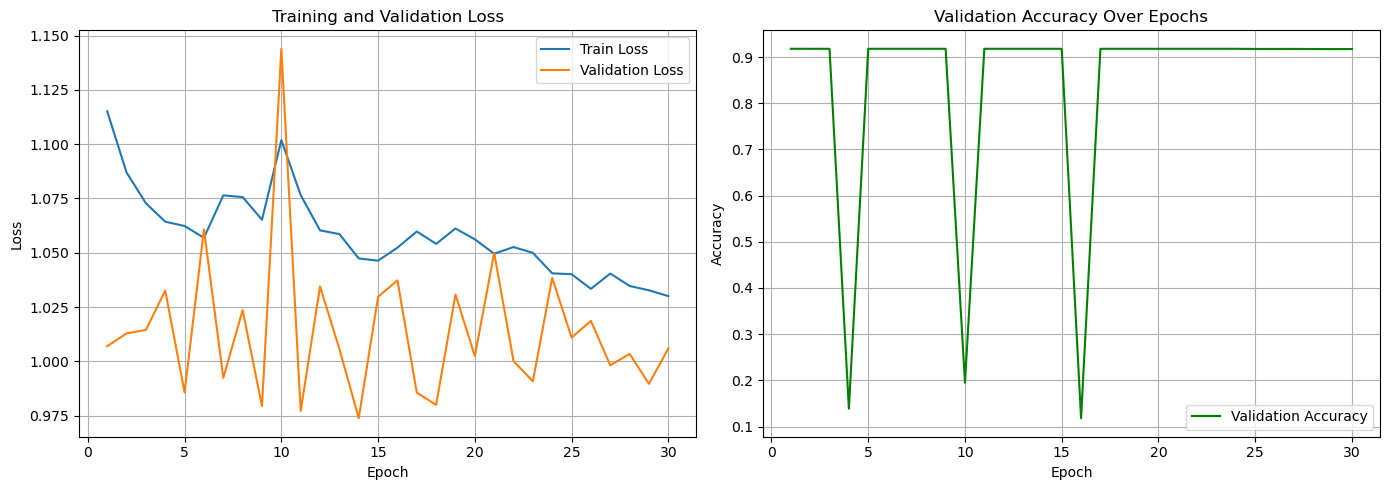

In [75]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [79]:
for _ in signals:
    print(_)

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


Total Return: 3.14%
Max Drawdown: -14.32%
Annualized Return: 0.26%
Annualized Volatility: 6.53%
Sharpe Ratio: 0.04


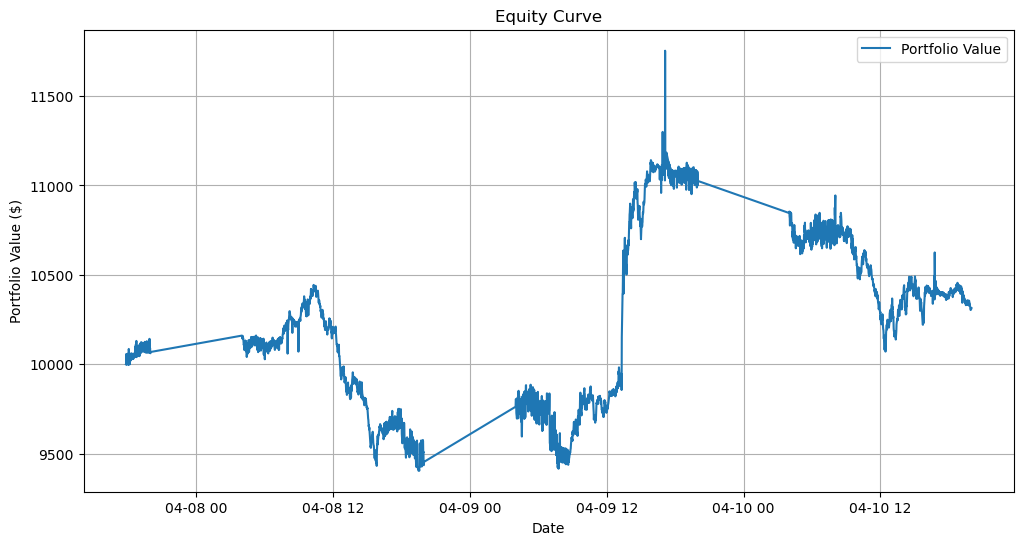

In [ ]:
import pandas as pd
import numpy as np

def backtest_trading_strategy(df, signals, initial_capital=10000, max_position_pct=0.1):
    """
    Backtest a trading strategy using model-generated signals.
    
    Parameters:
    - df: DataFrame with stock price data. Must contain columns ['Datetime', 'Ticker', 'Close'].
    - signals: DataFrame or array aligned with df that contains predicted signals:
               -1 = sell, 0 = hold, 1 = buy
    - initial_capital: Starting cash.
    - max_position_pct: Max fraction of portfolio to invest per trade (e.g., 0.1 = 10%)
    
    Returns:
    - portfolio_value: Series with portfolio value over time.
    - trades_log: DataFrame logging executed trades.
    """
    
    # Sort data by time
    df = df.copy()
    df = df.sort_values(['Ticker'])  # if you want to sort by time, use index
    df = df.reset_index()  # this moves 'Datetime' from index to a column
    df = df.sort_values(['Datetime', 'Ticker']).reset_index(drop=True)
    df = df.sort_values(['Datetime', 'Ticker']).reset_index(drop=True)
    
    # Align signals with df
    df['Signal'] = signals
    
    # Initialize portfolio state
    cash = initial_capital
    positions = {}  # key: ticker, value: shares held
    portfolio_value = []
    trade_log = []
    
    # Get unique timestamps
    times = df['Datetime'].unique()
    
    for t in times:
        df_t = df[df['Datetime'] == t]
        
        # Calculate total portfolio value at time t
        current_value = cash
        for ticker, shares in positions.items():
            # Get last close price for this ticker
            price = df_t[df_t['Ticker'] == ticker]['Close'].values
            if len(price) > 0:
                current_value += shares * price[0]
            else:
                # No price data at this timestamp, skip
                current_value += shares * df[df['Ticker'] == ticker].iloc[-1]['Close']
        
        # Record portfolio value
        portfolio_value.append({'Datetime': t, 'Portfolio Value': current_value})
        
        # Execute trades for this timestamp
        for _, row in df_t.iterrows():
            ticker = row['Ticker']
            price = row['Close']
            signal = row['Signal']
            
            position_size = max_position_pct * current_value
            
            shares_held = positions.get(ticker, 0)
            
            if signal == 1:  # Buy
                # Calculate max shares to buy
                max_shares_to_buy = int(position_size // price)
                if max_shares_to_buy > 0:
                    # Buy shares and update cash/position
                    cost = max_shares_to_buy * price
                    if cash >= cost:
                        cash -= cost
                        positions[ticker] = shares_held + max_shares_to_buy
                        trade_log.append({'Datetime': t, 'Ticker': ticker, 'Action': 'BUY',
                                          'Price': price, 'Shares': max_shares_to_buy, 'Cash': cash})
            
            elif signal == -1 and shares_held > 0:  # Sell all shares
                proceeds = shares_held * price
                cash += proceeds
                trade_log.append({'Datetime': t, 'Ticker': ticker, 'Action': 'SELL',
                                  'Price': price, 'Shares': shares_held, 'Cash': cash})
                positions[ticker] = 0
                
            # If signal == 0: hold, do nothing
            
        # Clean zero-share positions
        positions = {k: v for k, v in positions.items() if v > 0}
    
    portfolio_df = pd.DataFrame(portfolio_value).set_index('Datetime')
    trades_df = pd.DataFrame(trade_log)
    
    return portfolio_df, trades_df

import numpy as np

def performance_metrics(portfolio_df):
    # Portfolio value series
    pv = portfolio_df['Portfolio Value']
    
    # Daily returns
    returns = pv.pct_change().dropna()
    
    # Total return
    total_return = (pv.iloc[-1] / pv.iloc[0]) - 1
    
    # Max drawdown
    rolling_max = pv.cummax()
    drawdown = (pv - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Annualized return and volatility (assuming daily data, 252 trading days)
    trading_days = 252
    ann_return = (1 + total_return) ** (trading_days / len(pv)) - 1
    ann_volatility = returns.std() * np.sqrt(trading_days)
    
    # Sharpe ratio (risk-free rate = 0)
    sharpe_ratio = ann_return / ann_volatility if ann_volatility != 0 else np.nan
    
    print(f"Total Return: {total_return:.2%}")
    print(f"Max Drawdown: {max_drawdown:.2%}")
    print(f"Annualized Return: {ann_return:.2%}")
    print(f"Annualized Volatility: {ann_volatility:.2%}")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

import matplotlib.pyplot as plt

def plot_equity_curve(portfolio_df):
    plt.figure(figsize=(12,6))
    plt.plot(portfolio_df.index, portfolio_df['Portfolio Value'], label='Portfolio Value')
    plt.title("Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.grid(True)
    plt.legend()
    plt.show()



# Example usage:
# Assuming `df` is your price DataFrame and `signals` is a list/array aligned with df rows:
# portfolio, trades = backtest_trading_strategy(df, signals)

# Align df to last N rows, where N = length of signals
test_df = df.iloc[-len(signals):].copy()
test_df['Signal'] = signals


portfolio_df, trades_df = backtest_trading_strategy(test_df, test_df['Signal'].values, initial_capital=10000, max_position_pct=0.1)

# Calculate performance
performance_metrics(portfolio_df)

# Plot equity curve
plot_equity_curve(portfolio_df)